# Entrenamiento YOLO - WRO 2026

Objetivo:

- Detectar obstáculos rojo/verde como una única clase: `obstacle`.
- Detectar muros magenta de estacionamiento como: `parking_wall`.
- YOLO no clasificará rojo vs verde.
- El color será determinado posteriormente mediante un clasificador independiente.


In [45]:
%pip install -U ultralytics pyyaml matplotlib opencv-python

Note: you may need to restart the kernel to use updated packages.


In [64]:
from pathlib import Path
import random
import shutil
import yaml
import cv2
import matplotlib.pyplot as plt
import torch

from ultralytics import YOLO

import torch

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"

print("DEVICE:", DEVICE)

DEVICE: mps


In [47]:
ROOT = Path.cwd()

SOURCE_TRAIN = ROOT / "train"
SOURCE_IMAGES = SOURCE_TRAIN / "images"
SOURCE_LABELS = SOURCE_TRAIN / "labels"

SOURCE_YAML = ROOT / "data.yaml"

print("ROOT:", ROOT)
print("Imágenes:", SOURCE_IMAGES)
print("Labels:", SOURCE_LABELS)

ROOT: /Users/andresvillarreal/Documents/carrito7515/yolo/obstacles
Imágenes: /Users/andresvillarreal/Documents/carrito7515/yolo/obstacles/train/images
Labels: /Users/andresvillarreal/Documents/carrito7515/yolo/obstacles/train/labels


In [48]:
with open(SOURCE_YAML, "r") as f:
    original_data = yaml.safe_load(f)

original_data

{'train': '../train/images',
 'val': '../valid/images',
 'test': '../test/images',
 'nc': 3,
 'names': ['green', 'magenta', 'red'],
 'roboflow': {'workspace': 'izmir-ye64n',
  'project': 'obstacles-b16ad',
  'version': 1,
  'license': 'Public Domain',
  'url': 'https://universe.roboflow.com/izmir-ye64n/obstacles-b16ad/dataset/1'}}

In [49]:
names = original_data["names"]

if isinstance(names, list):
    class_names = {i: name for i, name in enumerate(names)}
else:
    class_names = {int(k): v for k, v in names.items()}

class_names

{0: 'green', 1: 'magenta', 2: 'red'}

In [50]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

images = [
    p for p in SOURCE_IMAGES.iterdir()
    if p.suffix.lower() in IMAGE_EXTENSIONS
]

print("Total imágenes:", len(images))

Total imágenes: 2559


In [51]:
from collections import Counter

counts = Counter()

for label_path in SOURCE_LABELS.glob("*.txt"):
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()

            if not parts:
                continue

            class_id = int(parts[0])
            counts[class_names[class_id]] += 1

counts

Counter({'magenta': 2188, 'red': 1658, 'green': 1163})

# Setear nombre de los targets


In [52]:
TARGET_NAMES = {
    0: "obstacle",
    1: "parking_wall"
}

In [53]:
class_mapping = {}

for old_id, name in class_names.items():
    name_lower = name.lower()

    if "red" in name_lower:
        class_mapping[old_id] = 0

    elif "green" in name_lower:
        class_mapping[old_id] = 0

    elif "magenta" in name_lower:
        class_mapping[old_id] = 1

class_mapping

{0: 0, 1: 1, 2: 0}

In [54]:
PREPARED = ROOT / "prepared"

for split in ["train", "val", "test"]:
    (PREPARED / "images" / split).mkdir(parents=True, exist_ok=True)
    (PREPARED / "labels" / split).mkdir(parents=True, exist_ok=True)

print(PREPARED)

/Users/andresvillarreal/Documents/carrito7515/yolo/obstacles/prepared


In [55]:
random.seed(42)
random.shuffle(images)

n = len(images)

n_train = int(n * 0.80)
n_val = int(n * 0.10)

train_images = images[:n_train]
val_images = images[n_train:n_train + n_val]
test_images = images[n_train + n_val:]

print("Train:", len(train_images))
print("Val:", len(val_images))
print("Test:", len(test_images))

Train: 2047
Val: 255
Test: 257


In [56]:
def convert_label(source_label, destination_label):
    new_lines = []

    if not source_label.exists():
        destination_label.write_text("")
        return

    with open(source_label, "r") as f:
        for line in f:
            parts = line.strip().split()

            if len(parts) != 5:
                continue

            old_class = int(parts[0])

            if old_class not in class_mapping:
                continue

            new_class = class_mapping[old_class]

            new_line = " ".join([
                str(new_class),
                *parts[1:]
            ])

            new_lines.append(new_line)

    destination_label.write_text("\n".join(new_lines))

In [57]:
def prepare_split(image_list, split):
    for image_path in image_list:

        destination_image = (
            PREPARED /
            "images" /
            split /
            image_path.name
        )

        shutil.copy2(image_path, destination_image)

        source_label = SOURCE_LABELS / f"{image_path.stem}.txt"

        destination_label = (
            PREPARED /
            "labels" /
            split /
            f"{image_path.stem}.txt"
        )

        convert_label(
            source_label,
            destination_label
        )

In [58]:
prepare_split(train_images, "train")
prepare_split(val_images, "val")
prepare_split(test_images, "test")

print("Dataset preparado.")

Dataset preparado.


In [59]:
prepared_yaml = {
    "path": str(PREPARED.resolve()),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": TARGET_NAMES,
}

PREPARED_YAML = PREPARED / "data.yaml"

with open(PREPARED_YAML, "w") as f:
    yaml.safe_dump(
        prepared_yaml,
        f,
        sort_keys=False
    )

print(PREPARED_YAML.read_text())

path: /Users/andresvillarreal/Documents/carrito7515/yolo/obstacles/prepared
train: images/train
val: images/val
test: images/test
names:
  0: obstacle
  1: parking_wall



In [60]:
def show_sample(image_path, label_path):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    if label_path.exists():
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) != 5:
                    continue

                cls, xc, yc, bw, bh = map(float, parts)

                xc *= w
                yc *= h
                bw *= w
                bh *= h

                x1 = int(xc - bw / 2)
                y1 = int(yc - bh / 2)
                x2 = int(xc + bw / 2)
                y2 = int(yc + bh / 2)

                cv2.rectangle(
                    image,
                    (x1, y1),
                    (x2, y2),
                    (255, 255, 255),
                    2
                )

                cv2.putText(
                    image,
                    TARGET_NAMES[int(cls)],
                    (x1, max(20, y1 - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (255, 255, 255),
                    2
                )

    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

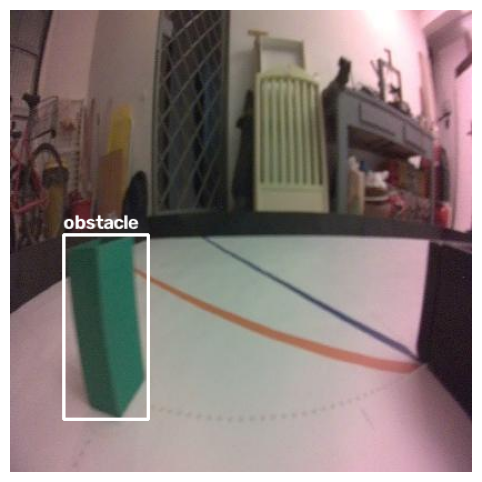

In [61]:
sample = random.choice(train_images)

show_sample(
    PREPARED / "images/train" / sample.name,
    PREPARED / "labels/train" / f"{sample.stem}.txt"
)

In [62]:
model = YOLO("yolo26n.pt")

In [67]:
model = YOLO("yolo26n.pt")

results = model.train(
    data=str(PREPARED_YAML),

    epochs=10,
    imgsz=320,
    batch=8,

    device="mps",

    freeze=10,

    cache=True,

    patience=5,

    project=str(ROOT / "runs"),
    name="wro_frozen"
)

Ultralytics 8.4.121 🚀 Python-3.10.18 torch-2.9.0 MPS (Apple M3)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/andresvillarreal/Documents/carrito7515/yolo/obstacles/prepared/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=wro

KeyboardInterrupt: 

# Entrenamos con el 50% del dataset como prueba


In [75]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")

results = model.train(
    data=str(PREPARED_YAML),

    epochs=20,
    imgsz=256,
    batch=8,

    device="mps",

    fraction=0.50,

    freeze=10,

    cache=True,

    patience=5,

    project=str(ROOT / "runs"),
    name="wro_50percent"
)

Ultralytics 8.4.121 🚀 Python-3.10.18 torch-2.9.0 MPS (Apple M3)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/andresvillarreal/Documents/carrito7515/yolo/obstacles/prepared/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.5, freeze=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=wro

# Entrenamos ahora con el 100% del dataset


In [ ]:
model_2 = YOLO("yolo26n.pt")

results = model_2.train(
    data=str(PREPARED_YAML),

    epochs=25,
    patience=8,

    imgsz=256,
    batch=8,

    device="mps",

    fraction=1.0,

    freeze=10,

    cache=True,

    project=str(ROOT / "runs"),
    name="wro_full"
)

Ultralytics 8.4.121 🚀 Python-3.10.18 torch-2.9.0 MPS (Apple M3)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/andresvillarreal/Documents/carrito7515/yolo/obstacles/prepared/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=wro

In [77]:
from pathlib import Path
import shutil

MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

source = ROOT / "runs" / "wro_full" / "weights" / "best.pt"
destination = MODELS_DIR / "wro_obstacle_detector.pt"

shutil.copy2(source, destination)

print("Modelo guardado en:")
print(destination)

Modelo guardado en:
/Users/andresvillarreal/Documents/carrito7515/yolo/obstacles/models/wro_obstacle_detector.pt


In [78]:
from ultralytics import YOLO

model = YOLO(
    "models/wro_obstacle_detector.pt"
)

model.export(
    format="ncnn",
    imgsz=256
)

Ultralytics 8.4.121 🚀 Python-3.10.18 torch-2.9.0 CPU (Apple M3)
WARNING ⚠️ NCNN export does not support end2end models, disabling end2end branch.
YOLO26n summary (fused): 146 layers, 2,495,084 parameters, 0 gradients, 0.8 GFLOPs

PyTorch: starting from 'models/wro_obstacle_detector.pt' with input shape (1, 3, 256, 256) BCHW and output shape(s) (1, 6, 1344) (5.1 MB)
requirements: Ultralytics requirement ['ncnn'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/6.4 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/6.4 MB ? eta -:--:--
   ━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/6.4 MB 6.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/6.4 MB 7.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/6.4 MB 7.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/6.4 MB 7.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/6.4 MB 2.2 MB/s eta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

pnnxparam = models/wro_obstacle_detector_ncnn_model/model.pnnx.param
pnnxbin = models/wro_obstacle_detector_ncnn_model/model.pnnx.bin
pnnxpy = models/wro_obstacle_detector_ncnn_model/model_pnnx.py
pnnxonnx = models/wro_obstacle_detector_ncnn_model/model.pnnx.onnx
ncnnparam = models/wro_obstacle_detector_ncnn_model/model.ncnn.param
ncnnbin = models/wro_obstacle_detector_ncnn_model/model.ncnn.bin
ncnnpy = models/wro_obstacle_detector_ncnn_model/model_ncnn.py
fp16 = 0
optlevel = 2
device = cpu
inputshape = [1,3,256,256]f32
inputshape2 = 
input = 
input2 = 
customop = 
moduleop = 
get inputshape from traced inputs
inputshape = [1,3,256,256]f32
############# pass_level0
inline module = torch.nn.modules.linear.Identity
inline module = ultralytics.nn.modules.block.Attention
inline module = ultralytics.nn.modules.block.Bottleneck
inline module = ultralytics.nn.modules.block.C2PSA
inline module = ultralytics.nn.modules.block.C3k
inline module = ultralytics.nn.modules.block.C3k2
inline module = 

NCNN: export success ✅ 26.1s, saved as 'models/wro_obstacle_detector_ncnn_model' (9.1 MB)

Export complete (27.2s)
Results saved to /Users/andresvillarreal/Documents/carrito7515/yolo/obstacles/models/wro_obstacle_detector_ncnn_model
Predict:         yolo predict task=detect model=models/wro_obstacle_detector_ncnn_model imgsz=256 
Validate:        yolo val task=detect model=models/wro_obstacle_detector_ncnn_model imgsz=256 data=/Users/andresvillarreal/Documents/carrito7515/yolo/obstacles/prepared/data.yaml  
Visualize:       https://netron.app


'models/wro_obstacle_detector_ncnn_model'

In [79]:
from ultralytics import YOLO

detector = YOLO(
    "models/wro_obstacle_detector_ncnn_model"
)

results = detector.predict(
    source="/Users/andresvillarreal/Documents/carrito7515/yolo/obstacles/prepared/images/test/image_0096_jpg.rf.b2b7fd0607f68fc0cd14ae248083e5a4.jpg",
    imgsz=256,
    conf=0.35
)

results[0].show()

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.
Loading models/wro_obstacle_detector_ncnn_model for NCNN inference...

image 1/1 /Users/andresvillarreal/Documents/carrito7515/yolo/obstacles/prepared/images/test/image_0096_jpg.rf.b2b7fd0607f68fc0cd14ae248083e5a4.jpg: 256x256 2 obstacles, 19.7ms
Speed: 40.7ms preprocess, 19.7ms inference, 68.5ms postprocess per image at shape (1, 3, 256, 256)
